### Importando as bibliotecas

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/despesas_ma_2025_tratado.csv", sep=";")

C:\Users\edils\AppData\Local\Temp\ipykernel_29764\3200093055.py:1: DtypeWarning: Columns (8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/despesas_ma_2025_tratado.csv", sep=";")


### Informações - Dataset

In [6]:
qtd_linhas, qtd_colunas = df.shape

print(f"O dataset possui total de {qtd_linhas} linhas e total de {qtd_colunas} colunas")

O dataset possui total de 1085608 linhas e total de 11 colunas


In [7]:
for colunas in df.columns:
    print(f"Coluna: {colunas}")

Coluna: ano
Coluna: mes
Coluna: fase
Coluna: codigo_unidade
Coluna: unidade
Coluna: valor
Coluna: codigo_credor
Coluna: credor_nome
Coluna: codigo_funcao
Coluna: codigo_natureza
Coluna: cod_grupo_despesa


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085608 entries, 0 to 1085607
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   ano                1085608 non-null  int64  
 1   mes                1085608 non-null  int64  
 2   fase               1085608 non-null  object 
 3   codigo_unidade     1085608 non-null  int64  
 4   unidade            1085608 non-null  object 
 5   valor              1085587 non-null  float64
 6   codigo_credor      1085608 non-null  object 
 7   credor_nome        1085608 non-null  object 
 8   codigo_funcao      1085595 non-null  object 
 9   codigo_natureza    1085608 non-null  object 
 10  cod_grupo_despesa  1085608 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 91.1+ MB


In [9]:
print(df['valor'].isna().sum())

21


In [10]:
df.describe()

,ano,mes,codigo_unidade,valor
count,1085608.0,1.085608e+06,1.085608e+06,1.085587e+06
mean,2025.0,7.363283e+00,2.583598e+05,5.178854e+06
std,0.0,3.265967e+00,1.479501e+05,1.058501e+08
min,2025.0,1.000000e+00,1.101030e+05,-5.358000e+09
25%,2025.0,5.000000e+00,1.701010e+05,6.000000e+03
50%,2025.0,8.000000e+00,2.109010e+05,1.660300e+04
75%,2025.0,1.000000e+01,2.402020e+05,7.800000e+04
max,2025.0,1.200000e+01,6.401010e+05,3.491304e+10


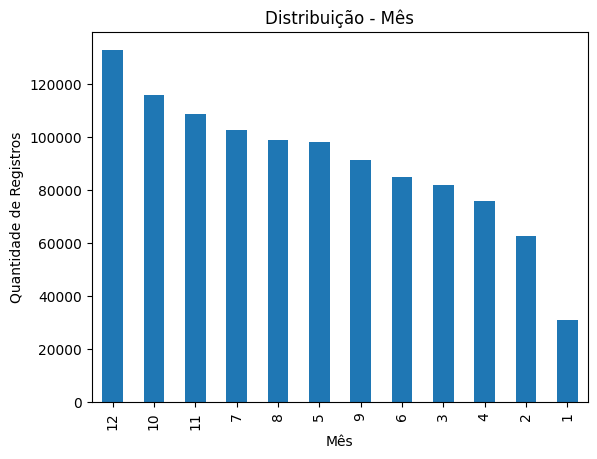

In [24]:
df['mes'].value_counts().plot(kind="bar")
plt.title("Distribuição - Mês")
plt.ylabel("Quantidade de Registros")
plt.xlabel("Mês")
plt.show()

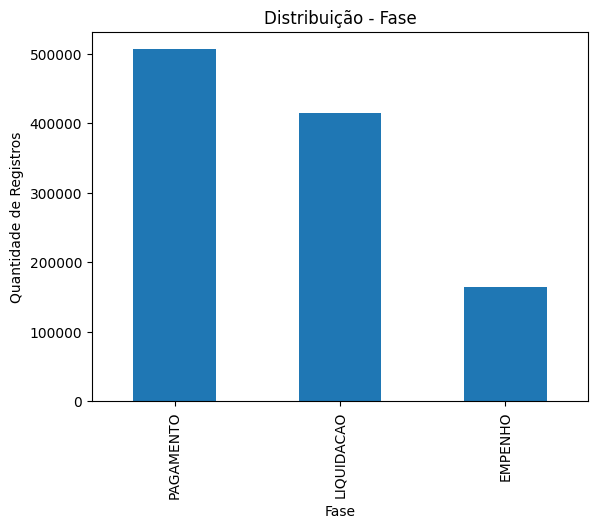

            Quantidade  Percentual (%)
fase                                  
PAGAMENTO       506467           46.65
LIQUIDACAO      415161           38.24
EMPENHO         163980           15.10


In [25]:
plt.title("Distribuição - Fase")
df["fase"].value_counts().plot(kind="bar")
plt.ylabel("Quantidade de Registros")
plt.xlabel("Fase")

plt.show()


contagem = df['fase'].value_counts()
percentual = df['fase'].value_counts(normalize=True).mul(100).round(2)

df_resumo = pd.DataFrame({'Quantidade': contagem, 'Percentual (%)': percentual})
print(df_resumo)

In [13]:
df['credor_nome'].value_counts()

credor_nome
BOLSISTAS                                                                                     130997
PAGAMENTO DE BOLSA FORMAÃÃO DESTINADO A PAGTO DE PROFISSIONAIS CONF.DECRETO 33.844/2018.     80859
AUXÃLIO ALIMENTAÃÃO                                                                         26193
PROGRAMA TRABALHO JOVEM                                                                        19330
TRIBUNAL DE JUSTICA DO MARANHAO                                                                17418
                                                                                               ...  
CONFIANCE MEDICAL PRODUTOS MEDICOS S.A                                                             1
WILNISON AZEVEDO SILVA                                                                             1
VIA DIRETA TELECOMUNICAÃÃES VIA SATELITE E INTERNET                                              1
A & M SOLUTION AGÃNCIA DIGITAL LTDA                                           

In [14]:
display(df["codigo_unidade"].value_counts())

codigo_unidade
170101    156217
240201    100476
170204     96307
240202     79513
210901     79511
           ...  
190185         6
540904         3
170901         2
190138         2
510901         2
Name: count, Length: 126, dtype: int64

In [15]:
valor_minimo = df["valor"].min()
valor_maximo = df["valor"].max()

print(f"A valor minimo: {valor_minimo} e valor máximo: {valor_maximo}")

A valor minimo: -5358000000.0 e valor máximo: 34913036878.0


In [16]:
#df[df['valor'].isna()]

In [17]:
valor_negativo=df[df["valor"]<=0]
display(valor_negativo.head(2))


linhas_negativo, colunas_negativo = valor_negativo.shape
print(f"Total de {linhas_negativo} linhas e Total de {colunas_negativo} colunas")

print(f"Valor Minino: {valor_negativo["valor"].min()} e valor Máximo: {valor_negativo["valor"].max()}")

,ano,mes,fase,codigo_unidade,unidade,valor,codigo_credor,credor_nome,codigo_funcao,codigo_natureza,cod_grupo_despesa
8,2025,1,EMPENHO,110103,Procuradoria Geral do Estado,-250000.0,07260360000171,SAO LUIS TELECOMUNICACOES LTDA,3.0,333903917,3
17,2025,1,EMPENHO,110103,Procuradoria Geral do Estado,-60000.0,11509434000138,WIKI TELECOMUNICAÃÃES LTDA.,3.0,333903958,3


Total de 20730 linhas e Total de 11 colunas
Valor Minino: -5358000000.0 e valor Máximo: -1.0


In [18]:
valor_positivo=df[df["valor"]>=0]
display(valor_positivo.head(2))


linhas_positivo, colunas_positivo = valor_positivo.shape
print(f"Total de {linhas_positivo} linhas e Total de {colunas_positivo} colunas")

print(f"Valor Minino: {valor_positivo["valor"].min()} e valor Máximo: {valor_positivo["valor"].max()}")

,ano,mes,fase,codigo_unidade,unidade,valor,codigo_credor,credor_nome,codigo_funcao,codigo_natureza,cod_grupo_despesa
0,2025,1,PAGAMENTO,110103,Procuradoria Geral do Estado,164832.0,29485582000125,"FP- PROJETOS, GERENCIAMENTOS, SERVIÃOS E EMPR...",3.0,333903916,3
1,2025,1,PAGAMENTO,110103,Procuradoria Geral do Estado,162405.0,29485582000125,"FP- PROJETOS, GERENCIAMENTOS, SERVIÃOS E EMPR...",3.0,333903916,3


Total de 1064857 linhas e Total de 11 colunas
Valor Minino: 1.0 e valor Máximo: 34913036878.0


In [49]:
df_pagamento = df[df["fase"] == "PAGAMENTO"].to_csv("Despesas_ma_2025_pagamentos")

df_pagamento

In [ ]:
display(df_pagamento.head())

qtd_linhas_pagamento , qtd_colunas_pagamento = df_pagamento.shape

print(f"Quantidade de {qtd_linhas_pagamento} linhas\nQuantidade de {qtd_colunas_pagamento} colunas")

AttributeError: 'NoneType' object has no attribute 'head'

In [42]:
display(df_pagamento['valor'].min())
display(df_pagamento['valor'].max())


quantidade = df_pagamento['valor'].value_counts()
percentual = df_pagamento['valor'].value_counts(normalize=True)*100



np.float64(1.0)

np.float64(34913036878.0)

In [43]:
dados = {
    "Quantidade":quantidade,
    "Percentual":percentual
}


df_percentual = pd.DataFrame(dados)
display(df_percentual)

,Quantidade,Percentual
valor,,
7000.0,24335,4.804920
6000.0,11809,2.331675
5000.0,9502,1.876160
3600.0,9096,1.795996
4000.0,8184,1.615922
...,...,...
527138.0,1,0.000197
673432.0,1,0.000197
768780.0,1,0.000197
